# SciPy 入门到进阶（Kaggle 风格教程）

**作者提示**：这是一个模仿 Kaggle 教学风格、面向实战的 SciPy 教程笔记本（中文）。内容由浅入深、配有代码示例和图形说明，适合想系统掌握 SciPy 常用模块（优化、积分、线性代数、信号处理、统计、插值、稀疏矩阵、特殊函数等）的同学。

**如何使用这个笔记本**
- 推荐在 Jupyter / JupyterLab / Colab 中运行（Colab 可以直接运行）。
- 如果缺少依赖，请运行下面的安装单元（通常已经预装 `numpy`, `scipy`, `matplotlib`, `pandas`）。
- 每个章节包含短小的理论介绍 + 一个或多个“动手实验”代码单元，运行并修改参数以加深理解。

下面的目录：
1. 快速准备（安装、导入）
2. SciPy 概览与子包介绍
3. 线性代数（`scipy.linalg`）
4. 优化与最小化（`scipy.optimize`）
5. 数值积分与常微分方程（`scipy.integrate`）
6. 插值（`scipy.interpolate`）
7. 傅里叶与信号处理（`scipy.fft` 与 `scipy.signal`）
8. 统计工具（`scipy.stats`）
9. 稀疏矩阵（`scipy.sparse`）
10. 特殊函数（`scipy.special`）
11. 空间算法（`scipy.spatial`）
12. 综合实战：带阻尼振子拟合 + 预测
13. 总结与学习建议

每一节都尽量保持“理论 + 代码 + 可视化 + 小结”的结构，方便学习和复现。开始吧！

In [13]:
# 如果需要，请取消下面一行注释并执行（在部分环境中可能需要）
# !pip install -q scipy numpy matplotlib pandas jupyter

# 基本导入（每个示例都会重复导入，以便单元独立运行）
import numpy as np  # 导入 numpy，常用的科学计算库，主要用于数组和矩阵运算
import scipy as sp  # 导入 scipy，科学计算的高级库，包含很多数学工具
import matplotlib.pyplot as plt  # 导入 matplotlib 的绘图库，用于画图

# 写一点显示设置
%matplotlib inline  
# 让画出的图直接显示在 Jupyter 笔记本中
plt.rcParams['figure.figsize'] = (8,4)  # 设置画图的默认大小
print('numpy:', np.__version__, 'scipy:', sp.__version__)  # 打印 numpy 和 scipy 的版本号

numpy: 2.0.2 scipy: 1.13.1


## 1）SciPy 是什么？为什么要用它？
- **SciPy** 是基于 NumPy 的科学计算库，提供了大量数值计算工具：优化、积分、线性代数、信号处理、统计分布、插值、稀疏矩阵、特殊函数等。
- 在数据科学/工程问题中，当 NumPy 提供基础数组与向量化运算时，SciPy 提供“可直接使用的数值算法” —— 你不需要自己实现数值优化或 ODE 求解器。
- 本教程的目标是：让你能**看到问题、选取子包、调用函数并理解输出**。每个章节会包含实战示例。

# 2）线性代数（`scipy.linalg`）
`scipy.linalg` 与 `numpy.linalg` 功能重叠，但 `scipy.linalg` 提供更多高级例程、对 LAPACK 的直接接口以及某些更高效的实现。

**要点**
- 解线性方程组 `Ax = b`：`scipy.linalg.solve`
- 特征值/特征向量：`scipy.linalg.eig`
- 奇异值分解（SVD）：`scipy.linalg.svd`
- 更稳定/高效的解法（例如使用 LU 或 Cholesky 分解）

下面用一个小例子演示常见操作。

In [14]:
import numpy as np  # 导入 numpy，用于数值计算
from scipy import linalg  # 导入 scipy 的线性代数模块

# 生成一个随机对称正定矩阵 A（便于用 Cholesky 分解）
rng = np.random.default_rng(0)  # 创建一个随机数生成器，种子为0，保证结果可复现
M = rng.standard_normal((5,5))  # 生成一个 5x5 的标准正态分布随机矩阵
A = np.dot(M.T, M) + np.eye(5)*1e-3  # 生成对称且接近正定的矩阵 A
b = rng.standard_normal(5)  # 生成一个长度为5的随机向量 b

# 1) 直接求解线性方程组 Ax = b
x_direct = linalg.solve(A, b)  # 用通用方法直接求解
print('直接解 x:', x_direct)

# 2) 用 Cholesky 分解（适合对称正定矩阵，更快更稳定）
c = linalg.cho_factor(A)  # 先对 A 做 Cholesky 分解
x_cholesky = linalg.cho_solve(c, b)  # 用分解结果求解 Ax = b
print('Cholesky 解 x:', x_cholesky)

# 验证两种方法的结果是否一致（L2范数越小越好）
print('误差（L2）:', np.linalg.norm(x_direct - x_cholesky))

# 3) 求矩阵的特征值和特征向量
w, v = linalg.eig(A)  # 计算特征值 w 和特征向量 v
print('特征值:', np.round(w, 4))  # 打印特征值，四位小数

# 4) 奇异值分解（SVD）示例
U, s, Vh = linalg.svd(A)  # 对 A 做 SVD 分解
print('奇异值 s:', np.round(s, 4))  # 打印奇异值

直接解 x: [ 1.55997885 -0.79105418 -0.99485415 -5.09247166  1.92704532]
Cholesky 解 x: [ 1.55997885 -0.79105418 -0.99485415 -5.09247166  1.92704532]
误差（L2）: 7.83946394196532e-15
特征值: [8.0803+0.j 6.6161+0.j 3.3686+0.j 0.2439+0.j 0.113 +0.j]
奇异值 s: [8.0803 6.6161 3.3686 0.2439 0.113 ]


**小结**
- `linalg.solve` 是通用解法，`cho_factor`/`cho_solve` 对对称正定矩阵更高效。
- SVD 可用于矩阵降秩、主成分分析（PCA 的底层计算之一）。
- 接下来我们将看参数拟合与优化的常见工具。

# 3）优化（`scipy.optimize`）
`scipy.optimize` 提供了：
- 标量/向量函数的最小化（`minimize`），支持多种算法（Nelder-Mead，BFGS，L-BFGS-B 等）
- 非线性方程求根（`root`, `brentq`, `bisect`）
- 曲线拟合（`curve_fit`：基于最小二乘）
- 还有全局优化（`differential_evolution`）

下面通过拟合“阻尼正弦（damped sine）”的合成数据来演示 `curve_fit`，这是机器学习/物理建模中常见的参数估计问题。

拟合参数： [3.19750735 0.61797148 1.50140352 0.49088596 0.15175923]
参数不确定度（std）： [0.19202207 0.05519772 0.00906287 0.06459963 0.0397711 ]
真实参数： (3.0, 0.6, 1.5, 0.5, 0.2)


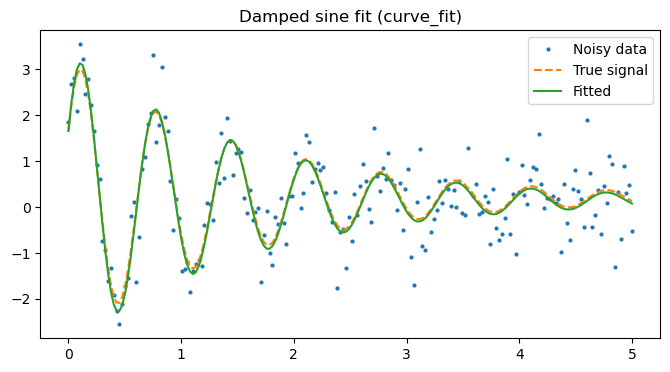

In [15]:
import numpy as np  # 导入 numpy
from scipy.optimize import curve_fit  # 导入 curve_fit，用于曲线拟合
import matplotlib.pyplot as plt  # 导入画图库

# 生成带噪声的阻尼正弦信号： y = A * exp(-gamma * t) * sin(2π f t + phi) + c
rng = np.random.default_rng(1)  # 创建随机数生成器，种子为1
def damped_sine(t, A, gamma, f, phi, c):
    # 定义阻尼正弦函数
    return A * np.exp(-gamma * t) * np.sin(2*np.pi*f*t + phi) + c

# 生成数据
t = np.linspace(0, 5, 200)  # 生成 0~5 的 200 个等间隔时间点
true_params = (3.0, 0.6, 1.5, 0.5, 0.2)  # 真实参数：振幅、阻尼、频率、初相位、偏置
y_clean = damped_sine(t, *true_params)  # 生成无噪声信号
y_noisy = y_clean + rng.normal(scale=0.6, size=t.shape)  # 加入高斯噪声

# 初始猜测参数（拟合时的起点）
p0 = [2.5, 0.5, 1.4, 0.0, 0.0]

# 使用 curve_fit 拟合参数
popt, pcov = curve_fit(damped_sine, t, y_noisy, p0=p0)  # popt为拟合参数，pcov为协方差矩阵
perr = np.sqrt(np.diag(pcov))  # 参数标准差（不确定度）

print('拟合参数：', popt)
print('参数不确定度（std）：', perr)
print('真实参数：', true_params)

# 可视化结果
plt.figure()
plt.plot(t, y_noisy, '.', markersize=4, label='Noisy data')  # 噪声数据
plt.plot(t, y_clean, '--', label='True signal')  # 真实信号
plt.plot(t, damped_sine(t, *popt), '-', label='Fitted')  # 拟合曲线
plt.legend()
plt.title('Damped sine fit (curve_fit)')
plt.show()

**说明与练习**
- `curve_fit` 基于最小二乘，适合噪声近似为高斯的情况。`pcov` 给出协方差矩阵，可用于估计参数误差。
- 实践练习：尝试用不同初始猜测 `p0`，观察是否会陷入局部极小值；尝试改变噪声强度，看看拟合置信区间如何变化。

In [16]:
from scipy.optimize import brentq, minimize  # 导入求根和最小化函数

# 求根（示例）: 求 cos(x) - x = 0 在区间 [0, 1] 的解
f = lambda x: np.cos(x) - x  # 定义函数 f(x)
root = brentq(f, 0, 1)  # 在区间 [0,1] 内用 brentq 方法求根
print('cos(x)-x 的根（brentq）:', root)

# 最小化示例（一个有多个极值点的函数）
g = lambda x: (x-2)**2 + 5*np.sin(3*x)   # 定义目标函数 g(x)，有多个极小值点
res = minimize(g, x0=10.0, method='BFGS')  # 用 BFGS 算法从 x0=10 开始寻找最小值
print('BFGS 找到的最小值点:', res.x, 'fun:', res.fun)

# 注意：不同算法结果可能不同，常用方法包括 Nelder-Mead, BFGS, L-BFGS-B（支持边界）等。

cos(x)-x 的根（brentq）: 0.7390851332151559
BFGS 找到的最小值点: [3.59381108] fun: -2.345562686625738


**小结**
- `brentq` 等单根方法需要区间，优点是稳健。
- `minimize` 是多用途工具，记得选择合适的算法与参数约束。

# 4）数值积分与常微分方程（`scipy.integrate`）
- 常用积分：`quad`（一维），`dblquad`（二维），`nquad`（多维）
- 常微分方程：推荐使用 `solve_ivp`（比老的 `odeint` 更现代，支持事件检测和多种求解器）

先做一个简单的积分示例，再解一个常见 ODE（阻尼振子）。

积分结果 I = 0.9999999999999997 估计误差 = 1.017819145094224e-08


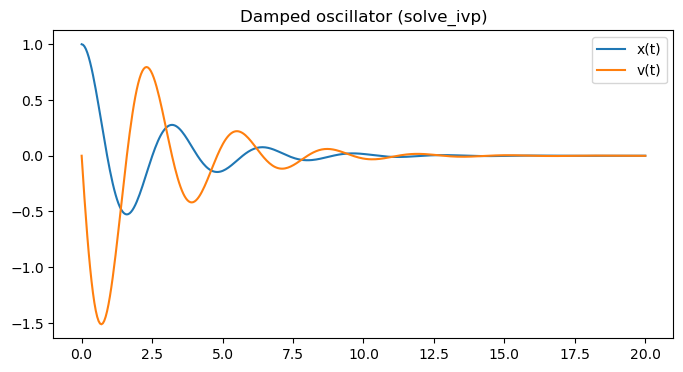

In [17]:
from scipy import integrate  # 导入积分和微分方程模块

# 1) 积分示例：积分高斯函数（标准正态分布的概率密度函数）从 -∞ 到 ∞，理论值为 1
f = lambda x: 1/np.sqrt(2*np.pi) * np.exp(-x**2/2)  # 定义标准正态分布的 pdf
I, err = integrate.quad(f, -np.inf, np.inf)  # 用 quad 计算积分，返回积分值和误差
print('积分结果 I =', I, '估计误差 =', err)

# 2) 解常微分方程：阻尼谐振子 x'' + 2ζω x' + ω^2 x = 0
## 首先将二阶方程转为一阶系统 u = [x, x']
def damped_osc(t, u, zeta=0.2, omega=2.0):
    x, v = u  # u[0]=x, u[1]=x'
    dxdt = v  # x'
    dvdt = -2*zeta*omega*v - omega**2 * x  # x''
    return [dxdt, dvdt]  # 返回一阶系统

t_span = (0, 20)  # 时间区间
u0 = [1.0, 0.0]  # 初始条件：初始位移为1，初始速度为0
sol = integrate.solve_ivp(lambda t,u: damped_osc(t,u, zeta=0.2, omega=2.0),
                          t_span, u0, t_eval=np.linspace(0,20,400))  # 求解微分方程

plt.figure()
plt.plot(sol.t, sol.y[0], label='x(t)')  # 画出位移随时间变化
plt.plot(sol.t, sol.y[1], label='v(t)')  # 画出速度随时间变化
plt.legend()
plt.title('Damped oscillator (solve_ivp)')  # 图标题
plt.show()

**练习**
- 改变阻尼系数 `zeta`，观察临界阻尼、欠阻尼和过阻尼的行为差异。
- 使用 `events` 参数在 `solve_ivp` 中检测特定事件（例如 x 值第一次过零）。

# 5）插值（`scipy.interpolate`）
常见函数：
- `interp1d`：线性/样条插值（1D）
- `UnivariateSpline`：带平滑项的样条
- `griddata`：不规则网格上的空间插值

示例：用样条对稀疏采样的曲线进行平滑与上采样。

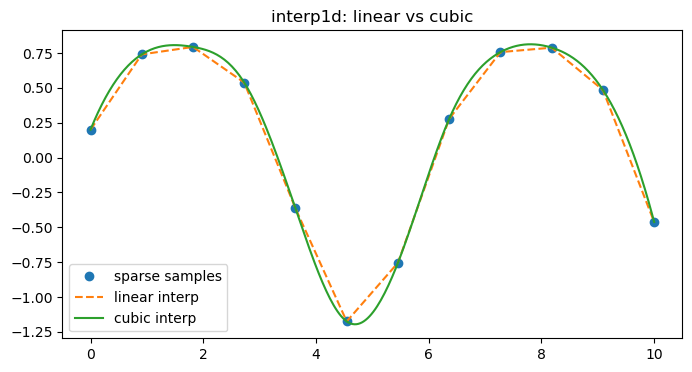

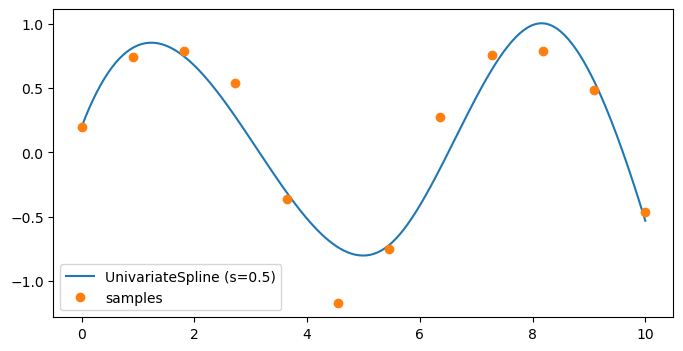

In [18]:
from scipy import interpolate  # 导入插值模块

# 构造稀疏采样的数据点
x_sparse = np.linspace(0, 10, 12)  # 0~10 之间取 12 个点
y_sparse = np.sin(x_sparse) + 0.2 * np.cos(2*x_sparse)  # 构造带有变化的曲线

# 线性插值和三次样条插值
f_lin = interpolate.interp1d(x_sparse, y_sparse, kind='linear')  # 线性插值函数
f_cubic = interpolate.interp1d(x_sparse, y_sparse, kind='cubic')  # 三次样条插值函数

x_dense = np.linspace(0, 10, 300)  # 更密集的采样点，用于画平滑曲线
y_lin = f_lin(x_dense)  # 线性插值结果
y_cubic = f_cubic(x_dense)  # 三次样条插值结果

plt.figure()
plt.plot(x_sparse, y_sparse, 'o', label='sparse samples')  # 原始稀疏点
plt.plot(x_dense, y_lin, '--', label='linear interp')  # 线性插值曲线
plt.plot(x_dense, y_cubic, '-', label='cubic interp')  # 三次样条插值曲线
plt.legend()
plt.title('interp1d: linear vs cubic')
plt.show()

# 示例：UnivariateSpline（带平滑因子 s）
spline = interpolate.UnivariateSpline(x_sparse, y_sparse, s=0.5)  # s=0.5 表示有一定平滑
plt.figure()
plt.plot(x_dense, spline(x_dense), label='UnivariateSpline (s=0.5)')  # 平滑插值曲线
plt.plot(x_sparse, y_sparse, 'o', label='samples')  # 原始点
plt.legend()
plt.show()

**提示**
- 对有噪声的数据，使用 `UnivariateSpline` 并设置合适的平滑参数 `s` 可以去噪。
- `griddata` 适用于二维或不规则采样点的插值（常用于地理/科学数据可视化）。

# 6）傅里叶与信号处理（`scipy.fft`, `scipy.signal`）
- `scipy.fft`：现代 FFT 接口（频谱分析）
- `scipy.signal`：滤波器设计（butter, filtfilt）、峰值检测（find_peaks）、短时傅里叶变换/谱图等

我们用合成信号演示 FFT 频谱识别与低通滤波去噪。

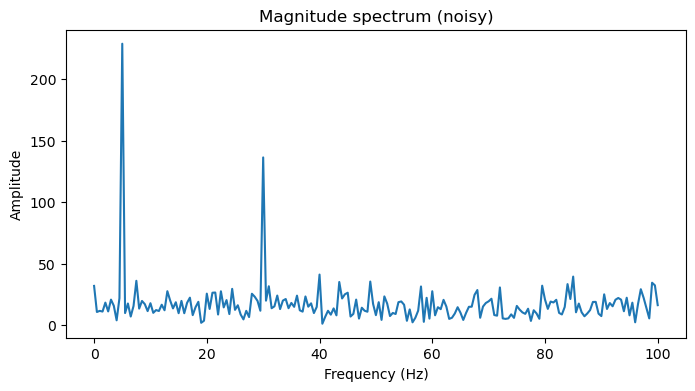

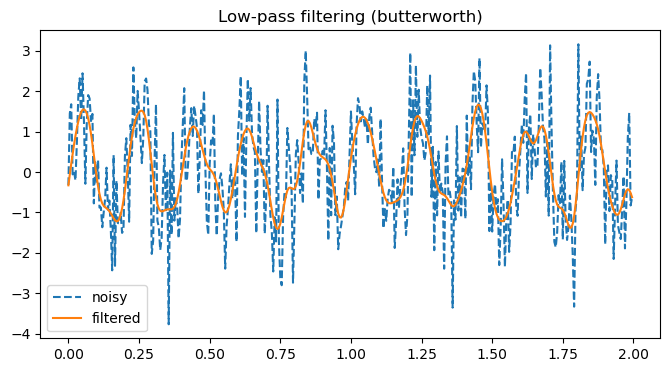

In [19]:
from scipy import fft, signal  # 导入傅里叶变换和信号处理模块

# 合成信号：两种不同频率的正弦波叠加，再加上高斯噪声
fs = 200.0  # 采样率，每秒采样200次
t = np.arange(0, 2.0, 1/fs)  # 生成0~2秒的时间点
sig = 1.2*np.sin(2*np.pi*5*t) + 0.6*np.sin(2*np.pi*30*t)  # 5Hz和30Hz的正弦波叠加
sig_noisy = sig + 0.9*np.random.normal(size=t.shape)  # 加入噪声

# 快速傅里叶变换（FFT），分析频谱
yf = fft.rfft(sig_noisy)  # 计算正频率部分的傅里叶变换
xf = fft.rfftfreq(len(t), 1/fs)  # 计算对应的频率坐标
plt.figure()
plt.plot(xf, np.abs(yf))  # 画出幅度谱
plt.title('Magnitude spectrum (noisy)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

# 设计低通 Butterworth 滤波器，截止频率为 15 Hz
b, a = signal.butter(4, 15, fs=fs, btype='low')  # 4阶低通滤波器
sig_filt = signal.filtfilt(b, a, sig_noisy)  # 对信号进行滤波

plt.figure()
plt.plot(t, sig_noisy, '--', label='noisy')  # 原始带噪声信号
plt.plot(t, sig_filt, '-', label='filtered')  # 滤波后信号
plt.legend()
plt.title('Low-pass filtering (butterworth)')
plt.show()

**练习**
- 修改采样率 fs，观察频谱缩放。
- 尝试不同阶数和截断频率的 Butterworth 滤波器，观察时域波形的相位和幅度响应变化。

# 7）统计（`scipy.stats`）
SciPy 的 `stats` 子包包含许多统计分布、检验方法和拟合工具：
- `scipy.stats.norm`, `gamma`, `t` 等分布：`rvs`, `pdf`, `cdf`, `fit`
- 假设检验：`ttest_ind`, `ks_2samp` 等
下面是一个分布拟合与检验的示例。

In [20]:
from scipy import stats  # 导入统计模块

# 生成数据，假设来自正态分布
rng = np.random.default_rng(2)  # 创建随机数生成器，种子为2
data = rng.normal(loc=5.0, scale=2.0, size=500)  # 生成均值5，标准差2的500个数据

# 用 scipy 拟合正态分布参数（最大似然估计）
mu_hat, sigma_hat = stats.norm.fit(data)  # 拟合出均值和标准差
print('拟合参数 mu, sigma =', mu_hat, sigma_hat)

# KS 检验：检验样本是否来自拟合的分布
D, pvalue = stats.kstest(data, 'norm', args=(mu_hat, sigma_hat))  # KS检验，D为统计量，pvalue为显著性水平
print('KS test D, p-value =', D, pvalue)

# t-test 示例：两组样本均值是否不同
group1 = rng.normal(0, 1, 60)  # 第一组数据，均值0，标准差1
group2 = rng.normal(0.5, 1.2, 70)  # 第二组数据，均值0.5，标准差1.2
tstat, p = stats.ttest_ind(group1, group2, equal_var=False)  # 独立样本t检验，判断均值是否有显著差异
print('Welch t-test: t=', tstat, 'p=', p)

拟合参数 mu, sigma = 4.893163460889726 2.024642868562179
KS test D, p-value = 0.027859907656459904 0.8219180837657651
Welch t-test: t= -3.0844185449917823 p= 0.0025257845075068413


**说明**
- 统计检验有许多前提（独立样本、方差齐性等），使用前务必确认假设。

# 8）稀疏矩阵（`scipy.sparse`）
在处理 PDE 离散化或大规模图结构时，矩阵通常非常稀疏。`scipy.sparse` 提供稀疏格式（CSR, CSC, COO）和稀疏求解器（`spsolve`, `cg`）。

示例：构造二维 Poisson（离散 Laplacian）并求解。

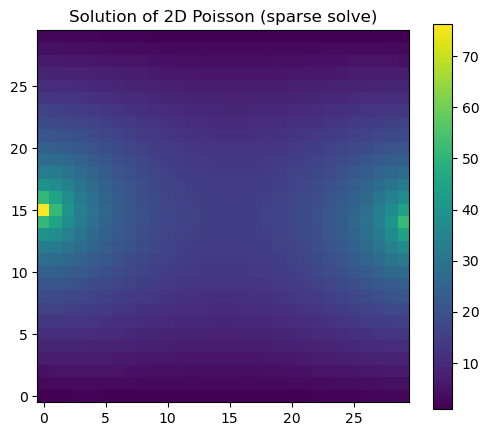

In [21]:
from scipy import sparse  # 导入稀疏矩阵模块
from scipy.sparse import linalg as spla  # 导入稀疏矩阵的线性代数工具

# 构造 2D Poisson 矩阵（五点差分，n x n 网格）
n = 30  # 网格大小
N = n*n  # 总未知数个数
diag = np.ones(N)*4  # 主对角线元素全为4
offdiag = np.ones(N-1)*-1  # 相邻对角线元素为-1
A = sparse.diags([diag, offdiag, offdiag, -1*np.ones(N-n), -1*np.ones(N-n)],
                 [0, -1, 1, -n, n], shape=(N, N), format='csr')  # 构造稀疏矩阵A

# 构造右端项（例如中心有脉冲）
b = np.zeros(N)  # 右端项全为0
b[N//2] = 100.0  # 中心点赋值100，模拟脉冲

# 用稀疏直接解法求解线性方程组
x = spla.spsolve(A, b)  # 求解 Ax = b

# 重塑回 2D 显示
X = x.reshape((n, n))  # 把一维解向量变成二维矩阵
plt.figure(figsize=(6,5))
plt.imshow(X, origin='lower')  # 显示为热力图
plt.colorbar()  # 添加颜色条
plt.title('Solution of 2D Poisson (sparse solve)')
plt.show()

**提示**
- 对于非常大的系统（>1e6 unknowns），考虑迭代法（`cg`, `bicgstab` 等）并利用预条件器（`LinearOperator`）。

# 9）特殊函数（`scipy.special`）
`scipy.special` 包含许多数值稳定实现的数学特殊函数：Gamma, Beta, Bessel, erf, erfc 等。下面示例绘制几个常见函数。

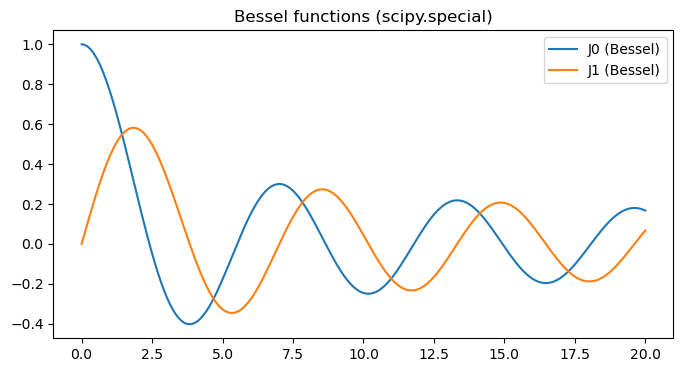

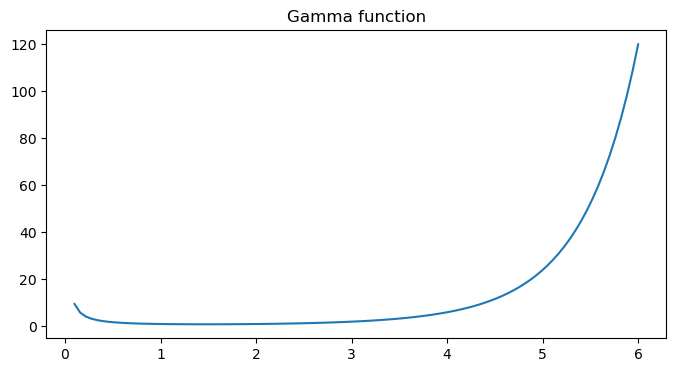

In [22]:
from scipy import special  # 导入特殊函数模块

x = np.linspace(0, 20, 200)  # 生成0~20的200个点
plt.figure()
plt.plot(x, special.jv(0, x), label='J0 (Bessel)')  # 0阶贝塞尔函数
plt.plot(x, special.jv(1, x), label='J1 (Bessel)')  # 1阶贝塞尔函数
plt.legend()
plt.title('Bessel functions (scipy.special)')
plt.show()

# Gamma 函数 & 正态化示例
xs = np.linspace(0.1, 6, 100)  # 生成0.1~6的100个点
plt.figure()
plt.plot(xs, special.gamma(xs), label='Gamma(x)')  # Gamma函数曲线
plt.title('Gamma function')
plt.show()

# 10）空间算法（`scipy.spatial`）
包含 KDTree、距离计算与空间分簇工具。KDTree 对邻近搜索非常高效。下面展示最近邻查找。

最近的点索引: [78 18 37]
对应距离: [0.09344876 0.09490273 0.117455  ]


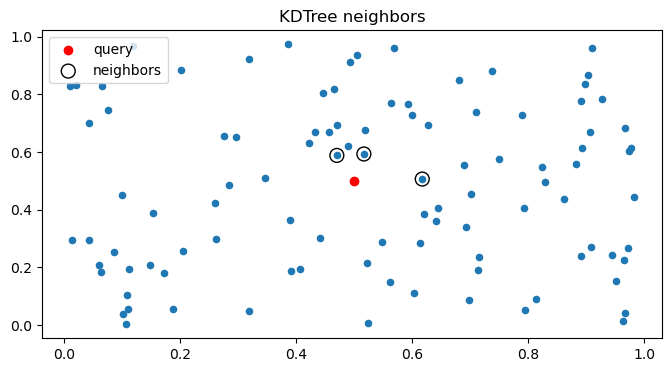

In [23]:
from scipy import spatial  # 导入空间算法模块

rng = np.random.default_rng(2)  # 创建随机数生成器，种子为2
points = rng.random((100, 2))  # 生成100个二维点，坐标在[0,1)
tree = spatial.KDTree(points)  # 用这些点构建KD树，便于快速查找最近邻

# 查询一个随机点的最近 3 个邻居
query_point = np.array([0.5, 0.5])  # 查询点坐标
dists, idxs = tree.query(query_point, k=3)  # 查找最近3个点的索引和距离
print('最近的点索引:', idxs)
print('对应距离:', dists)

plt.figure()
plt.scatter(points[:,0], points[:,1], s=20)  # 所有点
plt.scatter(query_point[0], query_point[1], c='red', label='query')  # 查询点
plt.scatter(points[idxs,0], points[idxs,1], edgecolors='k', facecolors='none', s=100, label='neighbors')  # 最近邻
plt.legend()
plt.title('KDTree neighbors')
plt.show()

# 11）综合实战：用观测数据拟合阻尼振子参数并预测
**任务**：给定一段观测到的阻尼振子时间序列（带噪声），估计振幅 A、阻尼系数 γ、频率 f、初相位 φ 和偏置 c。然后用估计的参数用 ODE 求解器预测更长时间范围内的行为。

本例结合 `optimize.curve_fit` 与 `integrate.solve_ivp`，展示如何把参数估计与数值模拟串联使用。

估计参数： [1.79912737 0.19901758 0.90825404 0.08951894 0.24531189]


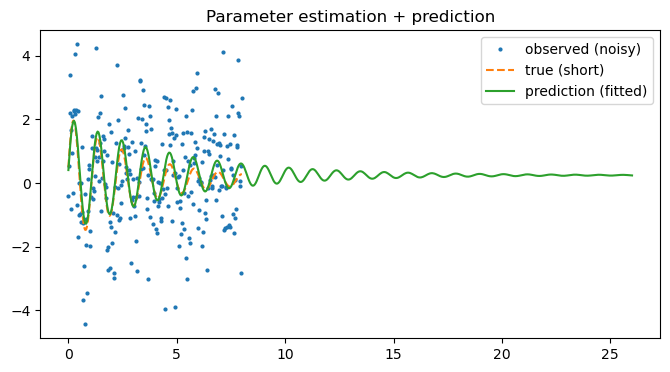

In [27]:

# 生成观测数据（真实系统由 ODE 支配）
def damped_ode_system(t, y, gamma, omega):
    # y = [x, v]，x为位移，v为速度
    x, v = y
    return [v, -2*gamma*omega*v - omega**2 * x]  # 返回一阶系统

# 真实参数（与前面类似）
A_true = 2.0  # 振幅
gamma_true = 0.3  # 阻尼系数
f_true = 0.9  # 频率
omega_true = 2*np.pi*f_true  # 角频率
phi_true = 0.2  # 初相位
c_true = 0.1  # 偏置

t_obs = np.linspace(0, 8, 300)  # 观测时间点
y_true = A_true * np.exp(-gamma_true * t_obs) * np.sin(omega_true * t_obs + phi_true) + c_true  # 真实信号
y_obs = y_true + np.random.default_rng(4).normal(scale=1.4, size=t_obs.shape)  # 加入噪声

# 拟合（使用 curve_fit）
p0 = [1.5, 1.0, 0.8, 0.0, 0.0]  # 初始猜测参数：A, gamma, f, phi, c
def model_for_fit(t, A, gamma, f, phi, c):
    # 用于拟合的模型函数
    return A * np.exp(-gamma * t) * np.sin(2*np.pi*f*t + phi) + c

popt, pcov = curve_fit(model_for_fit, t_obs, y_obs, p0=p0)  # 用观测数据拟合参数
print('估计参数：', popt)

# 用估计的参数通过 ODE 做预测（这里仍然可用解析表达式预测；此处演示两者结合）
A_est, gamma_est, f_est, phi_est, c_est = popt  # 拟合得到的参数
omega_est = 2*np.pi*f_est  # 拟合得到的角频率

t_pred = np.linspace(0, 26, 600)  # 预测更长时间范围
y_pred = A_est * np.exp(-gamma_est * t_pred) * np.sin(omega_est * t_pred + phi_est) + c_est  # 预测信号

plt.figure()
plt.plot(t_obs, y_obs, '.', markersize=4, label='observed (noisy)')  # 观测数据
plt.plot(t_obs, y_true, '--', label='true (short)')  # 真实短时信号
plt.plot(t_pred, y_pred, '-', label='prediction (fitted)')  # 拟合预测
plt.legend()
plt.title('Parameter estimation + prediction')
plt.show()

**讨论**
- 参数估计与 ODE 数值求解是常见的物理建模流程：先用观测数据拟合参数，再将参数代入数值模型用于预测或灵敏度分析。
- 若模型是复杂 ODE（不可解析），可以把 `solve_ivp` 嵌套到拟合流程中（代价较高），或使用延迟求导技巧、并行化加速。

# 12）结语与进阶路线
**学习建议**
- 通过动手实验熟悉每个子包：先运行示例，再尝试改变参数、输入规模或初始条件。
- 学会读 SciPy 的官方文档（API 说明 + Example），遇到性能瓶颈时考虑 `numba` 或 C/C++ 扩展。
- 更复杂的数值问题（大规模 PDE、可扩展优化）可能需要专业库（PETSc、CVXOPT 等），但 SciPy 对于中小规模任务已经非常强大。

**练习题（建议）**
1. 使用 `scipy.optimize.differential_evolution` 做全局搜索拟合阻尼振子，和 `curve_fit` 做对比。
2. 用 `scipy.sparse` 离散化 3D Poisson 方程并用 `cg` 求解（注意预条件）。
3. 用 `scipy.signal.spectrogram` 分析一段真实音频的时间-频率特性。

希望这个笔记本对你有帮助！如果你想，我可以：
- 把这个笔记本导出为 `.ipynb`（已生成），或者为 `.py` 脚本、或生成更短的速查手册；
- 根据你想学习的方向（物理建模、机器学习、图像处理等）定制练习与数据集。
